In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    low_memory=False
)

In [4]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [5]:
df.shape

(2075259, 9)

In [6]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='str')

In [7]:
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)

In [8]:
df.set_index(
    "Datetime",
    inplace=True
)

In [9]:
df["Global_active_power"] = pd.to_numeric(
    df["Global_active_power"],
    errors="coerce"
)

In [10]:
df["Global_active_power"] = df[
    "Global_active_power"
].fillna(
    df["Global_active_power"].mean()
)

In [11]:
daily_power = df[
    "Global_active_power"
].resample("D").mean()

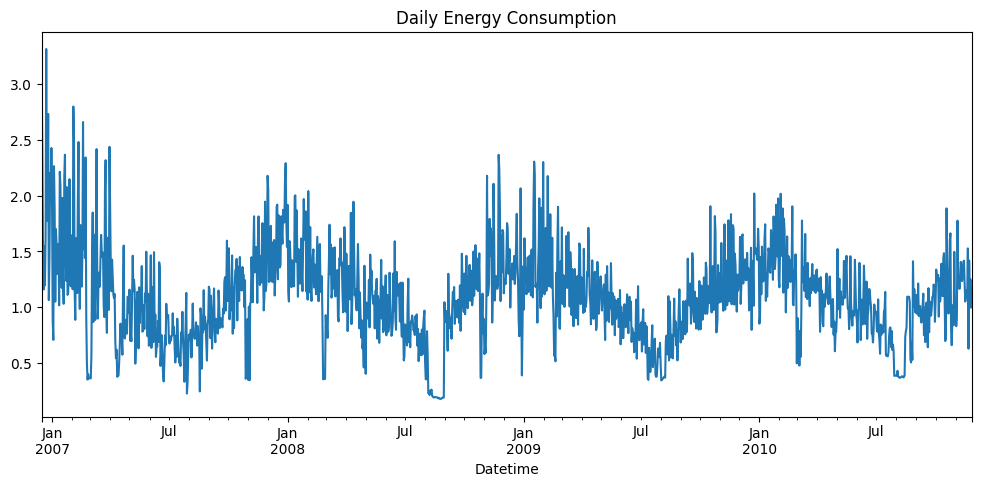

In [12]:
plt.figure(figsize=(12,5))

daily_power.plot()

plt.title("Daily Energy Consumption")

plt.show()

In [13]:
daily_df = daily_power.reset_index()

In [14]:
daily_df["Day"] = daily_df["Datetime"].dt.day

daily_df["Month"] = daily_df["Datetime"].dt.month

daily_df["Weekday"] = daily_df["Datetime"].dt.weekday

In [15]:
train_size = int(
    len(daily_df) * 0.8
)

train = daily_df[:train_size]

test = daily_df[train_size:]

In [16]:
from statsmodels.tsa.arima.model import ARIMA

In [17]:
model = ARIMA(
    train["Global_active_power"],
    order=(5,1,0)
)

In [18]:
model_fit = model.fit()

In [19]:
predictions = model_fit.forecast(
    steps=len(test)
)

In [20]:
mae = mean_absolute_error(
    test["Global_active_power"],
    predictions
)

print(mae)

0.5215874168581722


In [21]:
rmse = np.sqrt(
    mean_squared_error(
        test["Global_active_power"],
        predictions
    )
)

print(rmse)

0.5909520565243263


In [22]:
rmse = np.sqrt(
    mean_squared_error(
        test["Global_active_power"],
        predictions
    )
)

print(rmse)

0.5909520565243263


## Conclusion

Energy consumption data was analyzed and forecasted using time-series techniques.

ARIMA was used to predict future household energy usage.

Model performance was evaluated using MAE and RMSE.

The forecast closely followed historical consumption patterns.